In [113]:
# Imports and setup
import sys
import os
import pathlib
import random
import numpy as np
import yaml
import json
import pybullet as p
import pybullet_data
from PIL import Image
from IPython.display import display
from scipy.spatial.transform import Rotation as R

# Set seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
# Set environment variables for Jupyter
os.environ['PROJECT_DIR'] = str(pathlib.Path.cwd())
os.environ['NUMEXPR_MAX_THREADS'] = '90'
os.environ['HYDRA_FULL_ERROR'] = '1'
os.environ['CUDA_HOME'] = '/usr/local/cuda-11.8'


## Configuration

Set the asset directory and other parameters here.

In [114]:
# Configuration
ASSET_DIR = pathlib.Path("data/custom_objects/sim_microwave_good").resolve()
ENV_NAME = "articulated_custom_object"
NEAR_DISTANCE = 0.15
FAR_DISTANCE = 0.5
CENTER_JITTER = 0.05
SIZE_SCALE = (0.8, 1.1)
HANDLE_DILATE = 0.01
HANDLE_PART_ID = 1
HANDLE_PADDING = 0.0

print(f"Asset directory: {ASSET_DIR}")
print(f"Asset exists: {ASSET_DIR.exists()}")
print(f"Contents: {list(ASSET_DIR.iterdir())}")

Asset directory: /home/junting/repo/articulated_objects/GraspGen/GraspGenModels/custom_objects/sim_microwave_good
Asset exists: True
Contents: [PosixPath('/home/junting/repo/articulated_objects/GraspGen/GraspGenModels/custom_objects/sim_microwave_good/parts_render'), PosixPath('/home/junting/repo/articulated_objects/GraspGen/GraspGenModels/custom_objects/sim_microwave_good/mesh'), PosixPath('/home/junting/repo/articulated_objects/GraspGen/GraspGenModels/custom_objects/sim_microwave_good/predicted_grasps.yml'), PosixPath('/home/junting/repo/articulated_objects/GraspGen/GraspGenModels/custom_objects/sim_microwave_good/color_0025_0.urdf'), PosixPath('/home/junting/repo/articulated_objects/GraspGen/GraspGenModels/custom_objects/sim_microwave_good/experiment'), PosixPath('/home/junting/repo/articulated_objects/GraspGen/GraspGenModels/custom_objects/sim_microwave_good/base_config.yaml'), PosixPath('/home/junting/repo/articulated_objects/GraspGen/GraspGenModels/custom_objects/sim_microwave_go

## Step 1: Load and Parse Base Config

In [115]:
from manipulation.custom_object_utils.demo_utils import parse_config_metadata
from manipulation.custom_object_utils.object_utils import find_first_urdf, load_predicted_grasps
from manipulation.envs.articulated import handle_name_dict

# Load base config
config_path = ASSET_DIR / "base_config.yaml"
with open(config_path, 'r') as f:
    base_config = yaml.safe_load(f)
    
print("Base Config:")
for block in base_config:
    print(json.dumps(block, indent=2, default=str))
    print()

Base Config:
{
  "use_table": false
}

{
  "center": "(-0.0034383765556685653, 0.011455708268487871, 0.0)",
  "euler": "(0.04619989196455578, 0.0, 0.04619989196455578)",
  "orientation": "(0.023091729322869795, 0.0005335125988137777, 0.023091729322869795, 0.9994664874011862)",
  "lang": "a custom object",
  "name": "Sim Microwave Good",
  "on_table": false,
  "reward_asset_path": "/home/junting/repo/articulated_objects/GraspGen/GraspGenModels/custom_objects/sim_microwave_good",
  "size": 0.7024995506813487,
  "type": "urdf",
  "handle_name": "link1",
  "annotation_path": "data/custom_objects/sim_microwave_good/annotation.json"
}

{
  "solution_path": "/home/junting/repo/articulated_objects/GraspGen/GraspGenModels/custom_objects/sim_microwave_good"
}



In [116]:
# Parse metadata
object_name, handle_name, annotation_hint, solution_path = parse_config_metadata(str(config_path))
handle_name_dict[object_name] = handle_name

print(f"Object name: {object_name}")
print(f"Handle name: {handle_name}")
print(f"Annotation hint: {annotation_hint}")
print(f"Solution path: {solution_path}")

Object name: sim microwave good
Handle name: link1
Annotation hint: data/custom_objects/sim_microwave_good/annotation.json
Solution path: /home/junting/repo/articulated_objects/GraspGen/GraspGenModels/custom_objects/sim_microwave_good


In [117]:
# Find URDF
urdf_path = find_first_urdf(ASSET_DIR)
print(f"URDF path: {urdf_path}")
print(f"URDF exists: {urdf_path.exists()}")

# Annotation path
annotation_path = ASSET_DIR / "annotation.json"
print(f"Annotation path: {annotation_path}")
print(f"Annotation exists: {annotation_path.exists()}")

# Load annotation
if annotation_path.exists():
    with open(annotation_path, 'r') as f:
        annotation = json.load(f)
    print(f"Annotation keys: {annotation.keys()}")
    if 'affordable_points' in annotation:
        pts = np.array(annotation['affordable_points'])
        print(f"Affordable points shape: {pts.shape}")
        print(f"Affordable points min: {pts.min(axis=0)}")
        print(f"Affordable points max: {pts.max(axis=0)}")

URDF path: /home/junting/repo/articulated_objects/GraspGen/GraspGenModels/custom_objects/sim_microwave_good/color_0025_0.urdf
URDF exists: True
Annotation path: /home/junting/repo/articulated_objects/GraspGen/GraspGenModels/custom_objects/sim_microwave_good/annotation.json
Annotation exists: True
Annotation keys: dict_keys(['affordable_points'])
Affordable points shape: (5, 3)
Affordable points min: [-0.02952737  0.46179177 -0.02502948]
Affordable points max: [-0.00153573  0.49078646  0.00426628]


## Step 2: Load Predicted Grasps

In [118]:
# Load predicted grasps
predicted_grasps_path = ASSET_DIR / "predicted_grasps.yml"
predicted_grasps = None

if predicted_grasps_path.exists():
    print(f"Loading predicted grasps from {predicted_grasps_path}")
    predicted_grasps = load_predicted_grasps(predicted_grasps_path)
    grasps, confidences = predicted_grasps
    print(f"Loaded {len(grasps)} grasps")
    print(f"Confidence range: [{confidences.min():.3f}, {confidences.max():.3f}]")
    
    # Show top 5 grasps
    top_idx = np.argsort(confidences)[::-1][:5]
    print("\nTop 5 grasps:")
    for i, idx in enumerate(top_idx):
        pos = grasps[idx][:3, 3]
        print(f"  {i+1}. confidence={confidences[idx]:.3f}, pos={pos}")
else:
    print("No predicted_grasps.yml found!")

Loading predicted grasps from /home/junting/repo/articulated_objects/GraspGen/GraspGenModels/custom_objects/sim_microwave_good/predicted_grasps.yml
Loaded 100 grasps
Confidence range: [0.829, 0.934]

Top 5 grasps:
  1. confidence=0.934, pos=[-0.05834399  0.40220487 -0.08757459]
  2. confidence=0.933, pos=[-0.06372307  0.40193283 -0.09182238]
  3. confidence=0.930, pos=[-0.0664408   0.39086002 -0.0898556 ]
  4. confidence=0.925, pos=[-0.06973972  0.39428723 -0.11370736]
  5. confidence=0.923, pos=[-0.05799311  0.40015066 -0.05746691]


## Step 3: Create Variant Config

In [119]:
from manipulation.custom_object_utils.demo_utils import create_variant_config

# Create a variant config
variant_idx = 9999  # Use a unique index for debugging
variant_path = create_variant_config(
    str(config_path),
    ASSET_DIR,
    variant_idx,
    handle_name,
    annotation_path,
    CENTER_JITTER,
    SIZE_SCALE,
    urdf_path=urdf_path,
    predicted_grasps=predicted_grasps,
)

print(f"Variant config created at: {variant_path}")

# Load and display the variant config
with open(variant_path, 'r') as f:
    variant_config = yaml.safe_load(f)

print("\nVariant Config:")
for block in variant_config:
    print(json.dumps(block, indent=2, default=str))
    print()

Variant config created at: /home/junting/repo/articulated_objects/GraspGen/GraspGenModels/custom_objects/sim_microwave_good/configs/config_custom_9999.yaml

Variant Config:
{
  "use_table": false,
  "predicted_grasp_position": "(0.2321777035189027, 0.08123682319224983, 0.04510009374690324)",
  "predicted_grasp_orientation": "(-0.3248413334005412, 0.5277740804846223, 0.7141390571768534, -0.325481236168423)"
}

{
  "center": "(0.019761017625471937, 0.02132155668819153, 0.0)",
  "euler": "(0.04619989196455578, 0.0, 0.04619989196455578)",
  "orientation": "(0.023091729322869795, 0.0005335125988137777, 0.023091729322869795, 0.9994664874011862)",
  "lang": "a custom object",
  "name": "Sim Microwave Good",
  "on_table": false,
  "reward_asset_path": "/home/junting/repo/articulated_objects/GraspGen/GraspGenModels/custom_objects/sim_microwave_good",
  "size": 0.7623625524688679,
  "type": "urdf",
  "handle_name": "link1",
  "annotation_path": "/home/junting/repo/articulated_objects/GraspGen/Gr

## Step 4: Initialize PyBullet Environment

We'll initialize the environment manually to inspect the initial state.

In [120]:
# Helper function to render the scene
def render_pybullet(physics_client, target_pos=[0.4, 0, 0.3], distance=1.5, yaw=45, pitch=-30, width=640, height=480):
    """Render the PyBullet scene and return an RGB image."""
    view_matrix = p.computeViewMatrixFromYawPitchRoll(
        cameraTargetPosition=target_pos,
        distance=distance,
        yaw=yaw,
        pitch=pitch,
        roll=0,
        upAxisIndex=2,
    )
    proj_matrix = p.computeProjectionMatrixFOV(
        fov=60,
        aspect=width/height,
        nearVal=0.01,
        farVal=100,
    )
    _, _, rgba, depth, mask = p.getCameraImage(
        width, height,
        viewMatrix=view_matrix,
        projectionMatrix=proj_matrix,
        shadow=True,
        lightDirection=[1, 1, 1],
        physicsClientId=physics_client,
    )
    return Image.fromarray(rgba, 'RGBA')

def display_scene(physics_client, title="Scene", **kwargs):
    """Display the rendered scene."""
    print(f"=== {title} ===")
    img = render_pybullet(physics_client, **kwargs)
    display(img)
    return img

In [121]:
from manipulation.utils import build_up_env_gen, parse_center

# Build environment
print("Building environment...")
env, _ = build_up_env_gen(str(variant_path), ENV_NAME, render=False)
env.reset()

print(f"\nEnvironment ID: {env.id}")
print(f"URDF IDs: {env.urdf_ids}")
print(f"Object name: {env.object_name}")
print(f"Link name: {env.link_name}")

Building environment...

Environment ID: 3
URDF IDs: {'robot': 1, 'plane': 0, 'sim microwave good': 2}
Object name: sim microwave good
Link name: link1


=== DEBUG: Object Position Analysis ===
Object AABB min: (0.24701806562458775, -0.16458796605565587, 0.14156103316986887)
Object AABB max: (0.24911246575736076, -0.16240759660260604, 0.14365126603676512)
Object AABB center: [0.24806526569097426, -0.16349778132913095, 0.142606149603317]
OK: Object is above ground. aabb_min[2] = 0.1416

Base position: (0.24806526569097426, -0.16349778132913095, 0.142606149603317)
Base orientation: (0.02309172932286975, 0.0005335125988137764, 0.02309172932286975, 0.9994664874011863)

Config 'center': (0.019761017625471937, 0.02132155668819153, 0.0)
Config 'size': 0.7623625524688679

=== Initial Scene ===
=== Initial Scene (after env.reset) ===


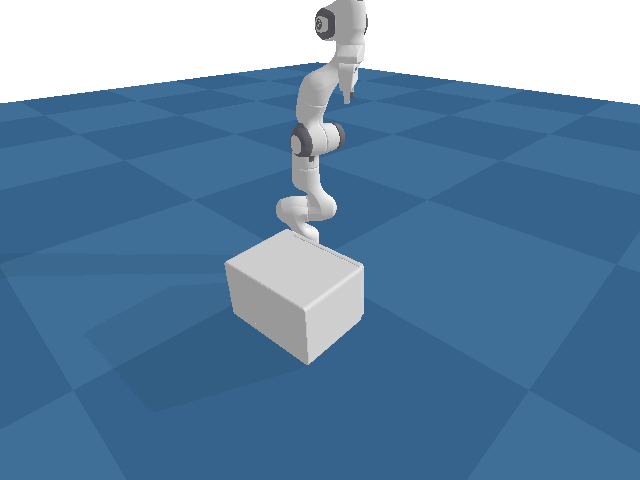

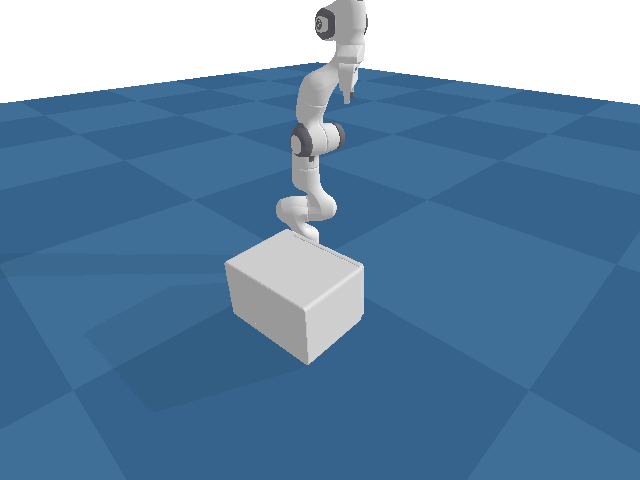

In [122]:
# Debug: Check object placement after env.reset()
print("=== DEBUG: Object Position Analysis ===")

# Get the object's AABB (Axis-Aligned Bounding Box)
object_id = env.urdf_ids[object_name]
aabb_min, aabb_max = p.getAABB(object_id, physicsClientId=env.id)
print(f"Object AABB min: {aabb_min}")
print(f"Object AABB max: {aabb_max}")
print(f"Object AABB center: {[(aabb_min[i] + aabb_max[i])/2 for i in range(3)]}")

# Check if the object is below ground (z < 0)
if aabb_min[2] < 0:
    print(f"WARNING: Object bottom is BELOW ground! aabb_min[2] = {aabb_min[2]:.4f}")
else:
    print(f"OK: Object is above ground. aabb_min[2] = {aabb_min[2]:.4f}")

# Get the base position as loaded
init_pos, init_orient = p.getBasePositionAndOrientation(object_id, physicsClientId=env.id)
print(f"\nBase position: {init_pos}")
print(f"Base orientation: {init_orient}")

# Check what position was used to load the object (from config)
for block in variant_config:
    if 'center' in block:
        print(f"\nConfig 'center': {block['center']}")
    if 'size' in block:
        print(f"Config 'size': {block['size']}")

# Display initial scene
print("\n=== Initial Scene ===")
display_scene(env.id, "Initial Scene (after env.reset)", target_pos=[init_pos[0], init_pos[1], 0.3])

In [123]:
# Debug: Check object bounding box and position after env.reset()
# This verifies the object placement fix (z=0 in base_config)

# Get object's AABB (Axis-Aligned Bounding Box)
obj_aabb_min, obj_aabb_max = p.getAABB(object_id, physicsClientId=env.id)
obj_aabb_min = np.array(obj_aabb_min)
obj_aabb_max = np.array(obj_aabb_max)

print("=== Object Placement Debug ===")
print(f"Object ID: {object_id}")
print(f"Object position (base): {init_pos}")
print(f"Object AABB min: {obj_aabb_min}")
print(f"Object AABB max: {obj_aabb_max}")
print(f"Object lowest point (z): {obj_aabb_min[2]:.4f}")
print(f"Object highest point (z): {obj_aabb_max[2]:.4f}")
print()

# Check if object is on the ground (lowest z should be close to 0)
if obj_aabb_min[2] < -0.01:
    print(f"⚠️  WARNING: Object appears to be BELOW ground level!")
    print(f"   Lowest point z = {obj_aabb_min[2]:.4f} (should be >= 0)")
elif obj_aabb_min[2] > 0.05:
    print(f"⚠️  WARNING: Object appears to be FLOATING above ground!")
    print(f"   Lowest point z = {obj_aabb_min[2]:.4f} (should be close to 0)")
else:
    print(f"✓ Object is properly placed on ground (lowest z = {obj_aabb_min[2]:.4f})")

# Check robot base position
robot_base_pos = p.getBasePositionAndOrientation(env.robot.body, physicsClientId=env.id)[0]
print(f"\nRobot base position: {robot_base_pos}")

# Check distance from robot to object
dist_to_object = np.linalg.norm(np.array(init_pos[:2]) - np.array(robot_base_pos[:2]))
print(f"Distance from robot to object (xy plane): {dist_to_object:.3f}m")

=== Object Placement Debug ===
Object ID: 2
Object position (base): (0.24806526569097426, -0.16349778132913095, 0.142606149603317)
Object AABB min: [ 0.24701807 -0.16458797  0.14156103]
Object AABB max: [ 0.24911247 -0.1624076   0.14365127]
Object lowest point (z): 0.1416
Object highest point (z): 0.1437

⚠️  WARNING: Object appears to be FLOATING above ground!
   Lowest point z = 0.1416 (should be close to 0)

Robot base position: (0.0, 0.0, 0.0)
Distance from robot to object (xy plane): 0.297m


In [124]:
# More detailed debug: Check all links' AABBs
print("=== Detailed Link AABB Debug ===")
num_joints = p.getNumJoints(object_id, physicsClientId=env.id)
print(f"Number of joints: {num_joints}")

# Get AABB for base link (-1)
all_aabbs = []
base_aabb = p.getAABB(object_id, -1, physicsClientId=env.id)
all_aabbs.append(base_aabb)
print(f"Base link (-1): min={np.array(base_aabb[0])}, max={np.array(base_aabb[1])}")

# Get AABB for all other links
for link_idx in range(num_joints):
    link_aabb = p.getAABB(object_id, link_idx, physicsClientId=env.id)
    all_aabbs.append(link_aabb)
    link_info = p.getJointInfo(object_id, link_idx, physicsClientId=env.id)
    link_name = link_info[12].decode('utf-8')
    print(f"Link {link_idx} ({link_name}): min={np.array(link_aabb[0])}, max={np.array(link_aabb[1])}")

# Compute overall bounding box
all_mins = np.array([aabb[0] for aabb in all_aabbs])
all_maxs = np.array([aabb[1] for aabb in all_aabbs])
overall_min = all_mins.min(axis=0)
overall_max = all_maxs.max(axis=0)
print(f"\nOverall AABB: min={overall_min}, max={overall_max}")
print(f"Overall object size: {overall_max - overall_min}")
print(f"Overall lowest point z: {overall_min[2]:.4f}")

if overall_min[2] < -0.01:
    print(f"\n⚠️  Object is BELOW ground by {-overall_min[2]:.4f}m")
else:
    print(f"\n✓ Object properly placed")

=== Detailed Link AABB Debug ===
Number of joints: 2
Base link (-1): min=[ 0.24701807 -0.16458797  0.14156103], max=[ 0.24911247 -0.1624076   0.14365127]
Link 0 (link0): min=[ 0.03166651 -0.45573334  0.        ], max=[ 0.45366172 -0.11012934  0.26519258]
Link 1 (link1): min=[ 0.0844992  -0.32823106  0.00184841], max=[0.44551404 0.05158613 0.28327984]

Overall AABB: min=[ 0.03166651 -0.45573334  0.        ], max=[0.45366172 0.05158613 0.28327984]
Overall object size: [0.4219952  0.50731947 0.28327984]
Overall lowest point z: 0.0000

✓ Object properly placed


## Step 5: Parse Config for Initial State Generation

In [125]:
# Parse config values
config = variant_config
urdf_center = None  # This is the URDF geometric center, NOT the world placement position
base_euler = None
target_position = None  # This is the actual world placement position
predicted_grasp_pos = None
predicted_grasp_orn = None

for config_dict in config:
    if 'center' in config_dict:
        # Note: 'center' is the URDF geometric center, not where we want to place the object
        urdf_center = parse_center(config_dict['center'])
    if 'euler' in config_dict:
        base_euler = parse_center(config_dict['euler'])
    if 'target_position' in config_dict:
        # This is the actual world placement position we want to use
        target_position = parse_center(config_dict['target_position'])
    if 'predicted_grasp_position' in config_dict:
        predicted_grasp_pos = parse_center(config_dict['predicted_grasp_position'])
    if 'predicted_grasp_orientation' in config_dict:
        predicted_grasp_orn = parse_center(config_dict['predicted_grasp_orientation'])

# Default target position: in front of robot, within arm workspace
# Robot base is at (0, 0, 0), so we place object at x=0.4 (in front)
if target_position is None:
    target_position = np.array([0.4, 0.0, 0.0])
    print("WARNING: No target_position in config, using default [0.4, 0, 0]")
    
if base_euler is None:
    base_euler = np.array([0.0, 0.0, 0.0])

print(f"URDF geometric center (NOT placement pos): {urdf_center}")
print(f"Target world position (for placement): {target_position}")
print(f"Base euler: {base_euler}")
print(f"Predicted grasp position (object frame): {predicted_grasp_pos}")
print(f"Predicted grasp orientation (object frame): {predicted_grasp_orn}")

URDF geometric center (NOT placement pos): [0.01976102 0.02132156 0.        ]
Target world position (for placement): [0.4 0.  0. ]
Base euler: [0.04619989 0.         0.04619989]
Predicted grasp position (object frame): [-0.07656726  0.40332079 -0.11067834]
Predicted grasp orientation (object frame): [0.59682661 0.24801888 0.20355577 0.73542483]


## Step 6: Sample Object Pose and Check Reachability

In [126]:
# Get object ID and initial pose - DEBUG ANALYSIS
object_id = env.urdf_ids[object_name]
init_pos, init_orient = p.getBasePositionAndOrientation(object_id, physicsClientId=env.id)
init_euler = p.getEulerFromQuaternion(init_orient)

print(f"Object ID: {object_id}")
print(f"Initial position (base): {init_pos}")
print(f"Initial orientation (quat): {init_orient}")
print(f"Initial orientation (euler): {init_euler}")

# Check AABB
aabb_min, aabb_max = p.getAABB(object_id, physicsClientId=env.id)
print(f"\nAABB min: {aabb_min}")
print(f"AABB max: {aabb_max}")
print(f"Object lowest point (min_z): {aabb_min[2]:.4f}")

# Check what the env stored as init_positions
print(f"\nenv.init_positions['{object_name}']: {env.init_positions.get(object_name, 'NOT FOUND')}")

# The formula used in adjust_object_positions:
# object_height = 2 * init_positions[name][2] - min_z
if object_name in env.init_positions:
    stored_z = env.init_positions[object_name][2]
    computed_height = 2 * stored_z - aabb_min[2]
    print(f"\nadjust_object_positions formula:")
    print(f"  stored_z (init_positions[2]): {stored_z:.4f}")
    print(f"  min_z (AABB lowest): {aabb_min[2]:.4f}")
    print(f"  computed_height = 2 * {stored_z:.4f} - {aabb_min[2]:.4f} = {computed_height:.4f}")
    
# For custom objects, we want the object to sit ON the ground (min_z = 0)
# So if the current min_z is negative, the object is BELOW ground
if aabb_min[2] < -0.01:
    print(f"\n⚠️ WARNING: Object is {abs(aabb_min[2]):.3f}m BELOW ground!")
elif aabb_min[2] > 0.01:
    print(f"\n⚠️ WARNING: Object is {aabb_min[2]:.3f}m ABOVE ground (floating)!")
else:
    print(f"\n✓ Object is properly sitting on ground (min_z ≈ 0)")

Object ID: 2
Initial position (base): (0.24806526569097426, -0.16349778132913095, 0.142606149603317)
Initial orientation (quat): (0.02309172932286975, 0.0005335125988137764, 0.02309172932286975, 0.9994664874011863)
Initial orientation (euler): (0.046199891964555685, 1.5178830414797062e-18, 0.046199891964555685)

AABB min: (0.24701806562458775, -0.16458796605565587, 0.14156103316986887)
AABB max: (0.24911246575736076, -0.16240759660260604, 0.14365126603676512)
Object lowest point (min_z): 0.1416

env.init_positions['sim microwave good']: [0.01976102 0.02132156 0.        ]

adjust_object_positions formula:
  stored_z (init_positions[2]): 0.0000
  min_z (AABB lowest): 0.1416
  computed_height = 2 * 0.0000 - 0.1416 = -0.1416

⚠️ WARNING: Object is 0.142m ABOVE ground (floating)!


In [127]:
# Robot arm joint limits
initial_joint_angles = [0 for _ in range(7)]
low = [-2.9, -1.8, -2.9, -3.1, -2.9, -0.0, -2.9]
high = [2.9, 1.8, 2.9, 0.0, 2.9, 3.8, 2.9]
for i in range(7):
    joint_range = high[i] - low[i]
    low[i] += joint_range * 0.2
    high[i] -= joint_range * 0.2

print(f"Joint limits (after 20% shrinkage):")
for i in range(7):
    print(f"  Joint {i}: [{low[i]:.3f}, {high[i]:.3f}]")

Joint limits (after 20% shrinkage):
  Joint 0: [-1.740, 1.740]
  Joint 1: [-1.080, 1.080]
  Joint 2: [-1.740, 1.740]
  Joint 3: [-2.480, -0.620]
  Joint 4: [-1.740, 1.740]
  Joint 5: [0.760, 3.040]
  Joint 6: [-1.740, 1.740]


In [128]:
# Sample a new object pose using TARGET_POSITION (not URDF center!)
# The object should be placed IN FRONT of the robot, not at the origin

# Get current object z position (already adjusted to sit on ground)
object_z = init_pos[2]

# Sample position around target_position (NOT urdf_center!)
new_pos = np.array([
    target_position[0] + np.random.uniform(-0.1, 0.1),  # Around x=0.4
    target_position[1] + np.random.uniform(-0.1, 0.1),  # Around y=0.0
    object_z  # Keep the z from init (already adjusted for ground)
])

new_orient = p.getQuaternionFromEuler([
    init_euler[0], 
    init_euler[1], 
    base_euler[2] + np.random.uniform(-np.pi / 6, np.pi / 6)
])

print(f"Target position: {target_position}")
print(f"Object Z (from env init): {object_z:.4f}")
print(f"Sampled object position: {new_pos}")
print(f"Sampled object orientation (quat): {new_orient}")

# Apply the new pose
p.resetBasePositionAndOrientation(object_id, new_pos, new_orient, physicsClientId=env.id)

# Verify placement
new_aabb_min, new_aabb_max = p.getAABB(object_id, physicsClientId=env.id)
print(f"\nAfter placement:")
print(f"  Object AABB min: {new_aabb_min}")
print(f"  Object AABB max: {new_aabb_max}")
print(f"  Lowest point z: {new_aabb_min[2]:.4f}")

# Check distance from robot
robot_base = p.getBasePositionAndOrientation(env.robot.body, physicsClientId=env.id)[0]
dist_xy = np.linalg.norm(np.array(new_pos[:2]) - np.array(robot_base[:2]))
print(f"  Distance from robot (xy): {dist_xy:.3f}m")

Target position: [0.4 0.  0. ]
Object Z (from env init): 0.1426
Sampled object position: [0.31161672 0.07323523 0.14260615]
Sampled object orientation (quat): (0.023031140484212467, 0.0017547554844607577, 0.07595010645499817, 0.9968440543689172)

After placement:
  Object AABB min: (0.31046992856297184, 0.07205067484387288, 0.14156103316986887)
  Object AABB max: (0.312763516304308, 0.07441978346610119, 0.14365126603676512)
  Lowest point z: 0.1416
  Distance from robot (xy): 0.320m


=== Scene after object pose sampling ===


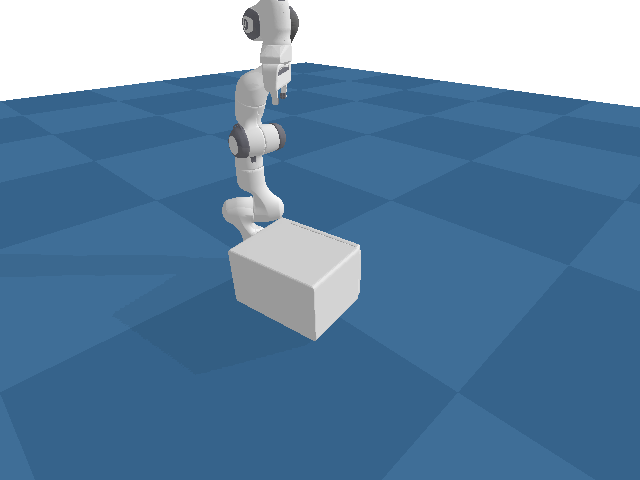

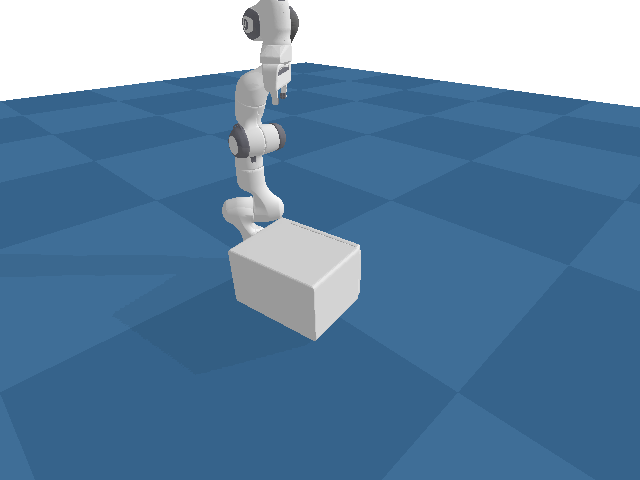

In [129]:
# Display scene after object pose change
display_scene(env.id, "Scene after object pose sampling")

In [130]:
# Compute grasp position in world frame
if predicted_grasp_pos is not None and predicted_grasp_orn is not None:
    grasp_pos_world, grasp_orn_world = p.multiplyTransforms(
        new_pos, new_orient, 
        predicted_grasp_pos, predicted_grasp_orn
    )
    print(f"Grasp position (world frame): {grasp_pos_world}")
    print(f"Grasp orientation (world frame): {grasp_orn_world}")
    
    # Visualize grasp point
    p.addUserDebugPoints([grasp_pos_world], [[1, 0, 0]], pointSize=20, lifeTime=0, physicsClientId=env.id)
else:
    print("No predicted grasp available!")
    grasp_pos_world = None

Grasp position (world frame): (0.17412030696868896, 0.4649275541305542, 0.050672657787799835)
Grasp orientation (world frame): (0.5934008359909058, 0.2891675531864166, 0.26343387365341187, 0.7034629583358765)


=== Scene with grasp point (red) ===


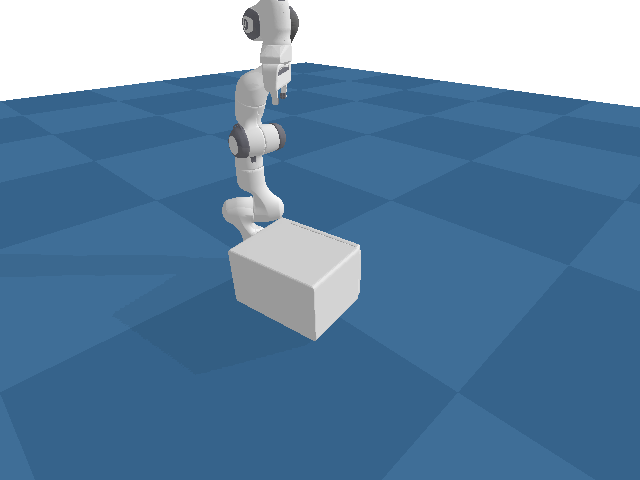

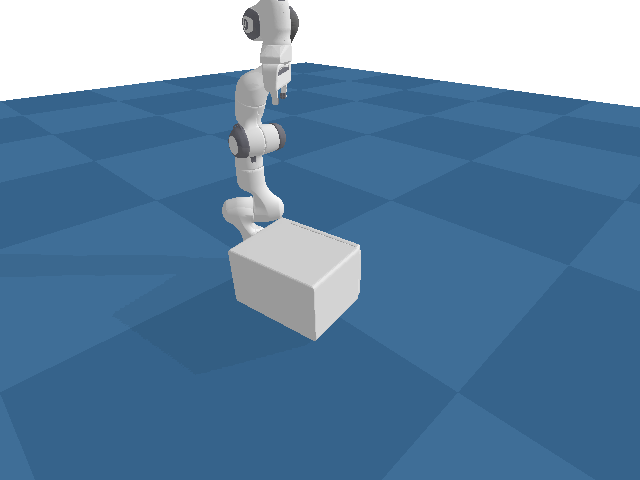

In [131]:
# Display scene with grasp point
display_scene(env.id, "Scene with grasp point (red)")

## Step 7: Sample Robot Configuration and Check Reachability

In [132]:
# Try to find a valid robot configuration
good_init_pos = False
max_attempts = 100

for test_time in range(max_attempts):
    # Randomly sample joint angles
    for i in range(7):
        initial_joint_angles[i] = np.random.uniform(low[i], high[i])
    
    env.robot.set_joint_angles(env.robot.right_arm_joint_indices, initial_joint_angles)
    for _ in range(5):
        p.stepSimulation(physicsClientId=env.id)
    
    # Check robot-object collision
    contact_points = p.getContactPoints(env.robot.body, object_id, physicsClientId=env.id)
    closest_points = p.getClosestPoints(env.robot.body, object_id, distance=0.01, physicsClientId=env.id)
    if len(contact_points) > 0 or len(closest_points) > 0:
        continue
    
    # Check robot-plane collision
    link_contact = False
    num_links = p.getNumJoints(env.robot.body, physicsClientId=env.id)
    for link_idx in range(1, num_links):
        contact_points = p.getClosestPoints(
            bodyA=env.robot.body, linkIndexA=link_idx,
            bodyB=env.urdf_ids['plane'], distance=0.01,
            physicsClientId=env.id
        )
        if len(contact_points) > 0:
            link_contact = True
            break
    if link_contact:
        continue
    
    # Check distance from EEF to grasp position
    robot_eef_pos, _ = env.robot.get_pos_orient(env.robot.right_end_effector)
    if grasp_pos_world is not None:
        distance = np.linalg.norm(np.array(grasp_pos_world) - np.array(robot_eef_pos))
        
        if distance < FAR_DISTANCE and distance > NEAR_DISTANCE:
            good_init_pos = True
            print(f"Found valid configuration at attempt {test_time+1}")
            print(f"  Joint angles: {initial_joint_angles}")
            print(f"  EEF position: {robot_eef_pos}")
            print(f"  Distance to grasp: {distance:.3f}m")
            break
        else:
            if test_time % 20 == 0:
                print(f"  Attempt {test_time+1}: distance={distance:.3f}m (need {NEAR_DISTANCE} < d < {FAR_DISTANCE})")

if not good_init_pos:
    print(f"\nFailed to find valid configuration after {max_attempts} attempts!")
    print("This is likely why gen_demo_custom.py times out.")

  Attempt 1: distance=1.035m (need 0.15 < d < 0.5)
Found valid configuration at attempt 3
  Joint angles: [-0.4650607853379529, -0.09488883409120241, 0.9924123456476874, -2.108606765185451, 0.04953584567936842, 2.110705217005457, -1.5783525637344078]
  EEF position: [0.46654934 0.27882294 0.28916542]
  Distance to grasp: 0.421m


=== Scene with sampled robot configuration ===


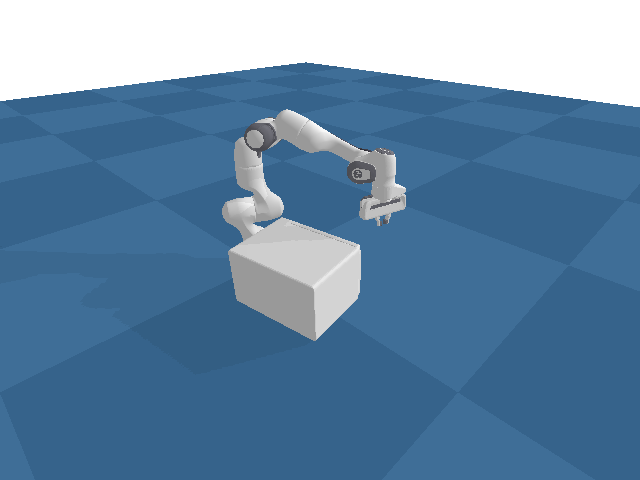

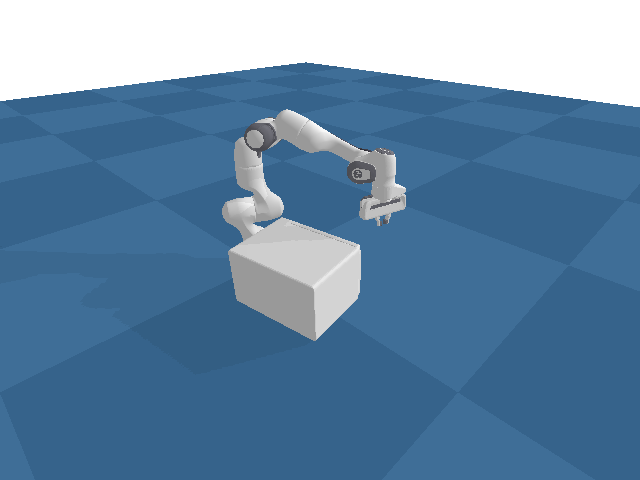

In [133]:
# Display scene with robot configuration
display_scene(env.id, "Scene with sampled robot configuration")

In [134]:
# Show EEF position
robot_eef_pos, robot_eef_orn = env.robot.get_pos_orient(env.robot.right_end_effector)
print(f"Robot EEF position: {robot_eef_pos}")
print(f"Robot EEF orientation: {robot_eef_orn}")

# Add debug visualization
p.addUserDebugPoints([robot_eef_pos], [[0, 1, 0]], pointSize=15, lifeTime=0, physicsClientId=env.id)

if grasp_pos_world is not None:
    # Draw line from EEF to grasp
    p.addUserDebugLine(robot_eef_pos, grasp_pos_world, [0, 0, 1], lineWidth=2, lifeTime=0, physicsClientId=env.id)

Robot EEF position: [0.46654934 0.27882294 0.28916542]
Robot EEF orientation: [0.13684786 0.99004494 0.00227052 0.03284095]


=== Scene with EEF (green) and grasp point (red), line connecting them (blue) ===


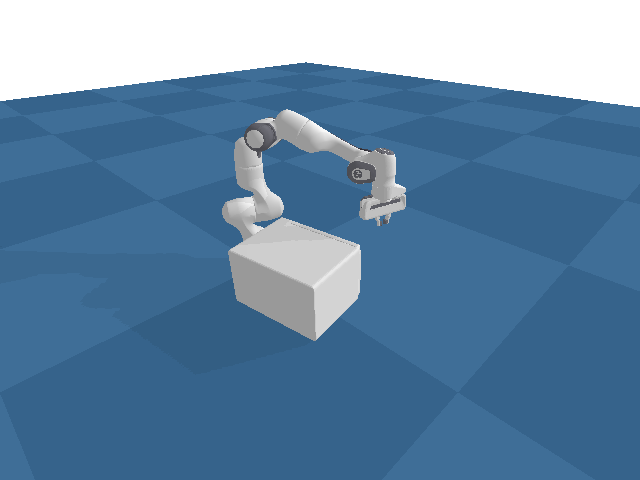

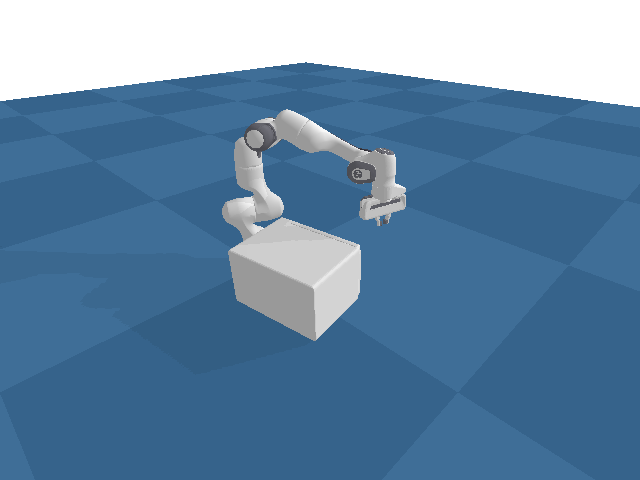

In [135]:
# Display final scene
display_scene(env.id, "Scene with EEF (green) and grasp point (red), line connecting them (blue)")

## Step 8: Visualize from Different Angles

=== Front view ===


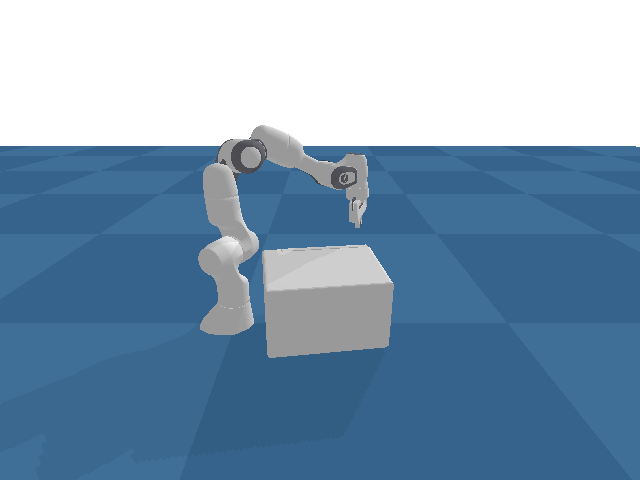

=== Side view ===


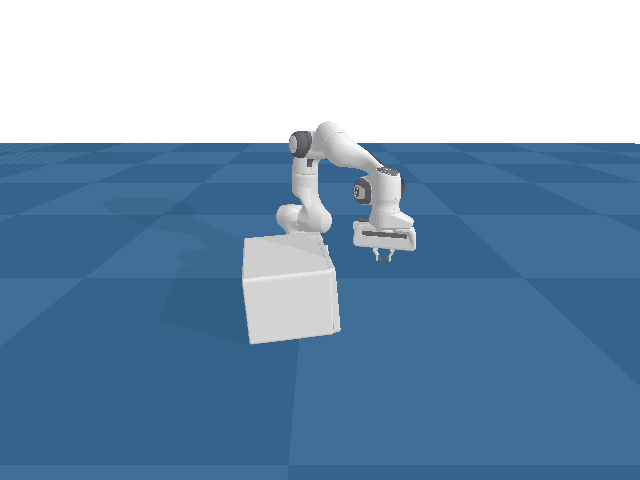

=== Top view ===


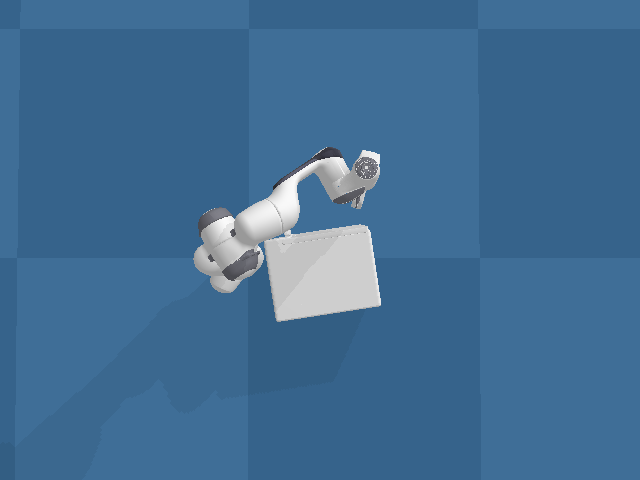

=== Isometric view ===


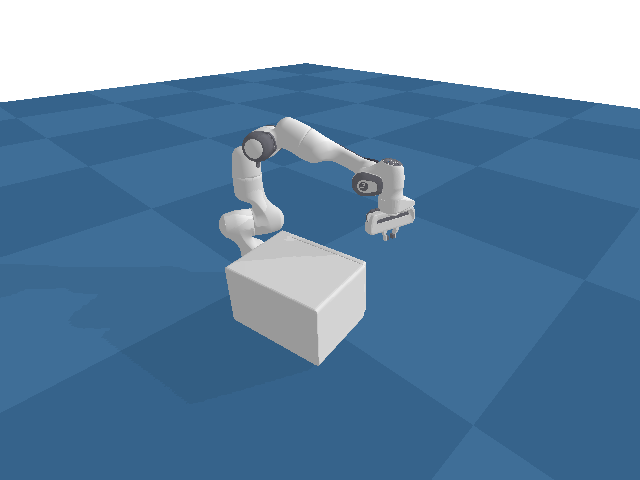

In [136]:
# Multiple views
views = [
    ("Front view", {"yaw": 0, "pitch": -20, "distance": 1.5}),
    ("Side view", {"yaw": 90, "pitch": -20, "distance": 1.5}),
    ("Top view", {"yaw": 0, "pitch": -89, "distance": 1.5}),
    ("Isometric view", {"yaw": 45, "pitch": -30, "distance": 1.5}),
]

for title, kwargs in views:
    display_scene(env.id, title, target_pos=[new_pos[0], new_pos[1], 0.3], **kwargs)

## Step 9: Analyze the Grasp Pose

Let's visualize the grasp orientation to understand if it's reasonable.

In [137]:
if predicted_grasp_pos is not None and predicted_grasp_orn is not None:
    # Convert grasp orientation to rotation matrix
    grasp_rot = R.from_quat(grasp_orn_world).as_matrix()
    
    # Draw coordinate axes at grasp point
    axis_length = 0.1
    origin = np.array(grasp_pos_world)
    
    # X axis (red)
    x_end = origin + grasp_rot[:, 0] * axis_length
    p.addUserDebugLine(origin.tolist(), x_end.tolist(), [1, 0, 0], lineWidth=3, lifeTime=0, physicsClientId=env.id)
    
    # Y axis (green)
    y_end = origin + grasp_rot[:, 1] * axis_length
    p.addUserDebugLine(origin.tolist(), y_end.tolist(), [0, 1, 0], lineWidth=3, lifeTime=0, physicsClientId=env.id)
    
    # Z axis (blue) - typically the approach direction
    z_end = origin + grasp_rot[:, 2] * axis_length
    p.addUserDebugLine(origin.tolist(), z_end.tolist(), [0, 0, 1], lineWidth=3, lifeTime=0, physicsClientId=env.id)
    
    print("Grasp coordinate frame:")
    print(f"  X axis (red): {grasp_rot[:, 0]}")
    print(f"  Y axis (green): {grasp_rot[:, 1]}")
    print(f"  Z axis (blue, approach): {grasp_rot[:, 2]}")

Grasp coordinate frame:
  X axis (red): [ 0.69396943  0.7138165  -0.09419357]
  Y axis (green): [-0.02744741  0.15695606  0.98722411]
  Z axis (blue, approach): [ 0.71948111 -0.68251798  0.12851512]


=== Grasp pose with coordinate axes (X=red, Y=green, Z=blue) ===


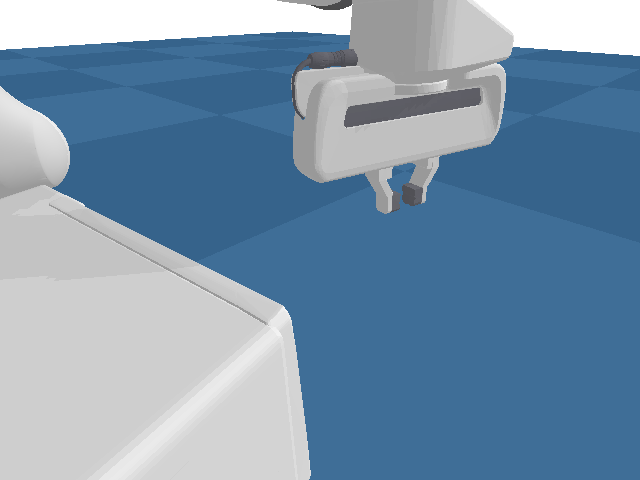

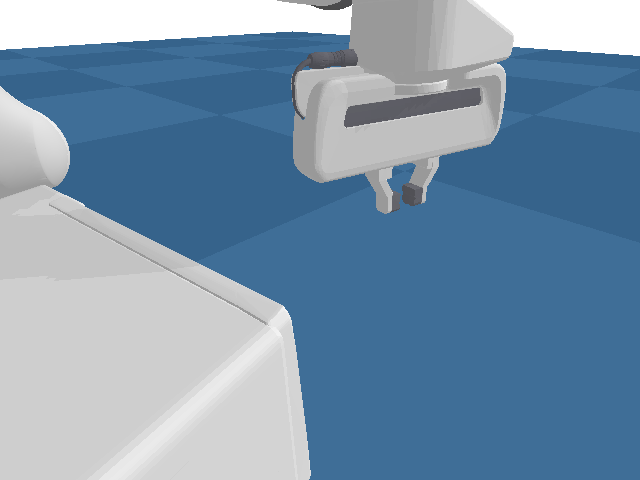

In [138]:
# Display scene with grasp axes
display_scene(env.id, "Grasp pose with coordinate axes (X=red, Y=green, Z=blue)",
              target_pos=list(grasp_pos_world) if grasp_pos_world else [0.4, 0, 0.3],
              distance=0.8, yaw=45, pitch=-30)

## Step 10: Check All Predicted Grasps

Visualize multiple grasp candidates to see which ones might be reachable.

In [139]:
if predicted_grasps is not None:
    grasps, confidences = predicted_grasps
    
    # Get top 10 grasps
    top_n = min(10, len(grasps))
    top_idx = np.argsort(confidences)[::-1][:top_n]
    
    print(f"Visualizing top {top_n} grasps:")
    
    # Get current object scale from config
    scale = 1.0
    for block in variant_config:
        if 'size' in block:
            # The scale was applied during variant config creation
            # We need to figure out what scale was used
            pass
    
    for rank, idx in enumerate(top_idx):
        grasp_mat = grasps[idx]
        pos_local = grasp_mat[:3, 3]  # Already scaled in create_variant_config
        rot_local = R.from_matrix(grasp_mat[:3, :3])
        quat_local = rot_local.as_quat()  # x, y, z, w
        
        # Transform to world frame
        pos_world, quat_world = p.multiplyTransforms(
            new_pos, new_orient,
            pos_local, quat_local
        )
        
        # Color based on rank (green = best, red = worst)
        color = [rank / top_n, 1 - rank / top_n, 0]
        p.addUserDebugPoints([pos_world], [color], pointSize=10, lifeTime=0, physicsClientId=env.id)
        
        # Check distance from robot base
        robot_base_pos = p.getBasePositionAndOrientation(env.robot.body, physicsClientId=env.id)[0]
        dist_to_base = np.linalg.norm(np.array(pos_world) - np.array(robot_base_pos))
        
        print(f"  Rank {rank+1}: conf={confidences[idx]:.3f}, pos={pos_world}, dist_to_robot={dist_to_base:.3f}m")

Visualizing top 10 grasps:
  Rank 1: conf=0.934, pos=(0.19246375560760498, 0.4655318260192871, 0.07370022684335709), dist_to_robot=0.509m
  Rank 2: conf=0.933, pos=(0.18715819716453552, 0.4646422266960144, 0.06944440305233002), dist_to_robot=0.506m
  Rank 3: conf=0.930, pos=(0.18616138398647308, 0.4532073736190796, 0.07089769840240479), dist_to_robot=0.495m
  Rank 4: conf=0.925, pos=(0.18221497535705566, 0.4571804404258728, 0.047229669988155365), dist_to_robot=0.494m
  Rank 5: conf=0.923, pos=(0.19333213567733765, 0.4621822237968445, 0.10368090867996216), dist_to_robot=0.512m
  Rank 6: conf=0.918, pos=(0.1805095672607422, 0.4452066421508789, 0.23883303999900818), dist_to_robot=0.537m
  Rank 7: conf=0.915, pos=(0.22029709815979004, 0.47479671239852905, 0.2611348032951355), dist_to_robot=0.585m
  Rank 8: conf=0.913, pos=(0.21272265911102295, 0.4763426184654236, 0.02927488088607788), dist_to_robot=0.523m
  Rank 9: conf=0.911, pos=(0.19680683314800262, 0.4586259126663208, 0.223634228110313

=== All grasp candidates (green=best, red=worst) ===


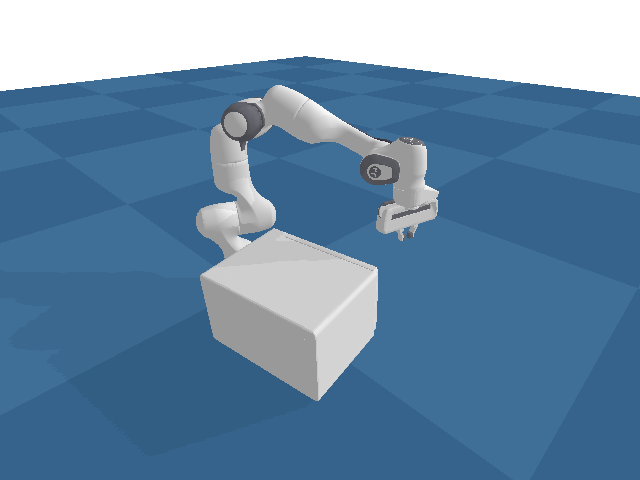

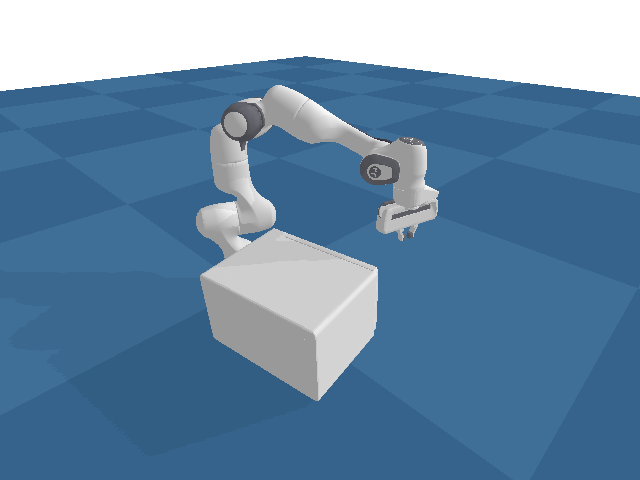

In [140]:
# Display scene with all grasp candidates
display_scene(env.id, "All grasp candidates (green=best, red=worst)",
              target_pos=[new_pos[0], new_pos[1], 0.3], distance=1.2, yaw=45, pitch=-30)

## Step 11: Visualize Motion Planning Target

Use the new visualization utilities to clearly show the grasp target and pre-grasp pose that motion planning will use.

In [142]:
# Import the new visualization utilities (simplified API using p.rotateVector)
# Reload module in case it was previously imported with old version
import importlib
import manipulation.custom_object_utils.visualization_utils as vis_utils
importlib.reload(vis_utils)

from manipulation.custom_object_utils.visualization_utils import (
    draw_pose_axes,
    draw_gripper,
    visualize_grasp,
    visualize_grasp_candidates,
    visualize_motion_target,
    clear_debug_items,
)

print("Visualization utilities loaded successfully!")

Visualization utilities loaded successfully!


In [143]:
# Clear previous debug visualizations and recreate environment for clean visualization
# Disconnect and recreate environment (if connected)
try:
    env.close()
except:
    pass  # Already closed

# Rebuild environment
print("Rebuilding environment for visualization...")
env, _ = build_up_env_gen(str(variant_path), ENV_NAME, render=False)
env.reset()

# Get object info
object_id = env.urdf_ids[object_name]
init_pos, init_orient = p.getBasePositionAndOrientation(object_id, physicsClientId=env.id)
init_euler = p.getEulerFromQuaternion(init_orient)

# Sample new position around target_position
new_pos = np.array([
    target_position[0] + np.random.uniform(-0.05, 0.05),
    target_position[1] + np.random.uniform(-0.05, 0.05),
    init_pos[2]
])
new_orient = p.getQuaternionFromEuler([
    init_euler[0], init_euler[1], 
    base_euler[2] + np.random.uniform(-np.pi / 8, np.pi / 8)
])
p.resetBasePositionAndOrientation(object_id, new_pos, new_orient, physicsClientId=env.id)

print(f"Object repositioned to: {new_pos}")

Rebuilding environment for visualization...
Object repositioned to: [ 0.41075449 -0.03294759  0.14260615]


In [144]:
# Visualize all predicted grasps with the new utilities
if predicted_grasps is not None:
    grasps, confidences = predicted_grasps
    
    print("=== Visualizing All Predicted Grasps ===")
    print(f"Total grasps: {len(grasps)}")
    print(f"Top 5 will be shown with gripper visualization")
    print()
    
    # Visualize top 5 grasps (uses new simplified API)
    vis_result = visualize_grasp_candidates(
        grasps, confidences,
        new_pos, new_orient,
        env.id,
        top_n=5,
        show_gripper=True,
        show_axes=True,
        show_labels=True,
    )
    
    # Print info for each grasp
    print("Grasp positions in world frame:")
    for grasp in vis_result["grasps"]:
        print(f"  #{grasp['rank']}: conf={grasp['confidence']:.3f}, pos={grasp['position']}")
else:
    print("No predicted grasps available!")

=== Visualizing All Predicted Grasps ===
Total grasps: 100
Top 5 will be shown with gripper visualization

Grasp positions in world frame:
  #1: conf=0.934, pos=(0.47308415174484253, 0.3722795844078064, 0.07370021939277649)
  #2: conf=0.933, pos=(0.4679160714149475, 0.37377333641052246, 0.06944439560174942)
  #3: conf=0.930, pos=(0.46206945180892944, 0.3638957440853119, 0.07089769840240479)
  #4: conf=0.925, pos=(0.46023082733154297, 0.3691852390766144, 0.047229669988155365)
  #5: conf=0.923, pos=(0.4724176228046417, 0.36888405680656433, 0.10368090122938156)


=== All Predicted Grasps (gripper visualization) ===


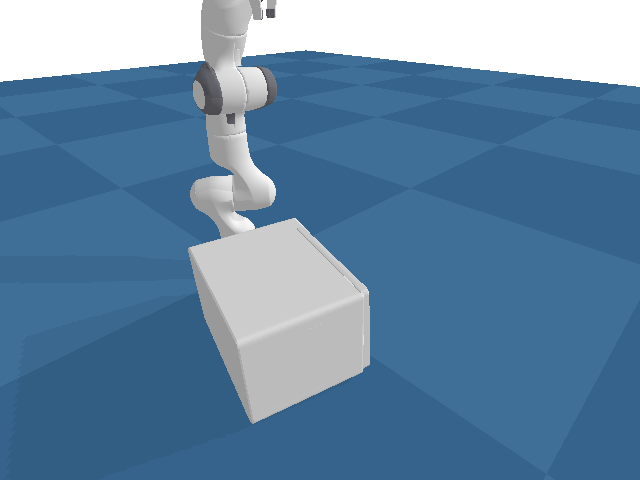

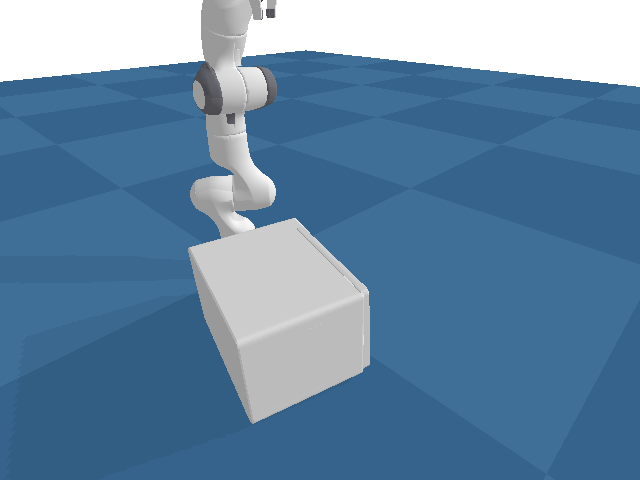

In [145]:
# Display scene with all grasps visualized
display_scene(env.id, "All Predicted Grasps (gripper visualization)",
              target_pos=[new_pos[0], new_pos[1], 0.3], distance=1.0, yaw=45, pitch=-30)

In [146]:
# Visualize the MOTION PLANNING TARGET
# This is the specific grasp that will be used for motion planning

print("=== Motion Planning Target Visualization ===")

if predicted_grasp_pos is not None and predicted_grasp_orn is not None:
    # Transform the selected grasp to world frame
    grasp_pos_world, grasp_orn_world = p.multiplyTransforms(
        new_pos, new_orient,
        predicted_grasp_pos.tolist(), predicted_grasp_orn.tolist()
    )
    
    print(f"Selected grasp (from variant config):")
    print(f"  Local position: {predicted_grasp_pos}")
    print(f"  Local orientation: {predicted_grasp_orn}")
    print(f"  World position: {grasp_pos_world}")
    print(f"  World orientation: {grasp_orn_world}")
    
    # Visualize with motion planning target (shows pre-grasp and approach)
    # Uses simplified API with p.rotateVector
    mp_result = visualize_motion_target(
        grasp_pos_world, grasp_orn_world,
        env.id,
        pre_grasp_offset=0.1,  # 10cm pre-grasp offset
        show_pre_grasp=True,
    )
    
    print(f"\nPre-grasp position: {mp_result.get('pre_grasp_pos', 'N/A')}")
    
    # Print distance info
    robot_eef_pos = env.robot.get_pos_orient(env.robot.right_end_effector)[0]
    robot_base_pos = p.getBasePositionAndOrientation(env.robot.body, physicsClientId=env.id)[0]
    dist_to_eef = np.linalg.norm(np.array(grasp_pos_world) - np.array(robot_eef_pos))
    dist_to_base = np.linalg.norm(np.array(grasp_pos_world) - np.array(robot_base_pos))
    print(f"\n=== Grasp Distance Info ===")
    print(f"  Distance from EEF: {dist_to_eef:.4f}m")
    print(f"  Distance from robot base: {dist_to_base:.4f}m")
else:
    print("ERROR: No predicted grasp available for motion planning!")

=== Motion Planning Target Visualization ===
Selected grasp (from variant config):
  Local position: [-0.07656726  0.40332079 -0.11067834]
  Local orientation: [0.59682661 0.24801888 0.20355577 0.73542483]
  World position: (0.45628541707992554, 0.37967216968536377, 0.050672657787799835)
  World orientation: (0.6427710652351379, 0.1502925008535385, 0.10077909380197525, 0.7443796992301941)

Pre-grasp position: [0.4209549017250538, 0.4723360389471054, 0.037821151316165924]

=== Grasp Distance Info ===
  Distance from EEF: 0.8569m
  Distance from robot base: 0.5957m


=== Motion Planning Target (green=grasp, yellow=pre-grasp) ===


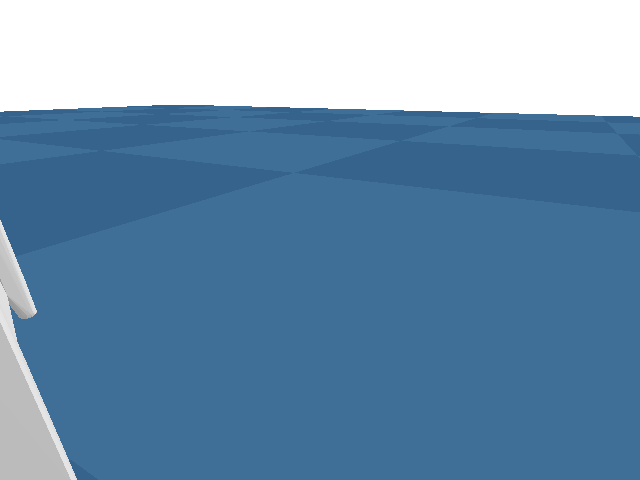

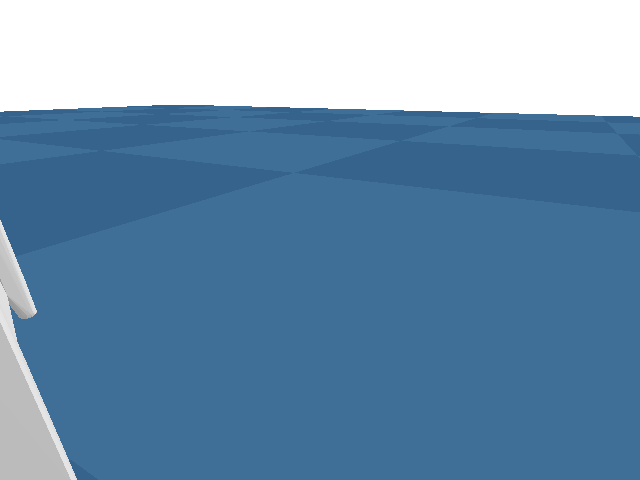

In [ ]:
# Display scene with motion planning target
display_scene(env.id, "Motion Planning Target (green=grasp, yellow=pre-grasp)",
              target_pos=list(grasp_pos_world), distance=0.6, yaw=30, pitch=-20)

=== Multiple Views of Motion Planning Target ===
=== Front view ===


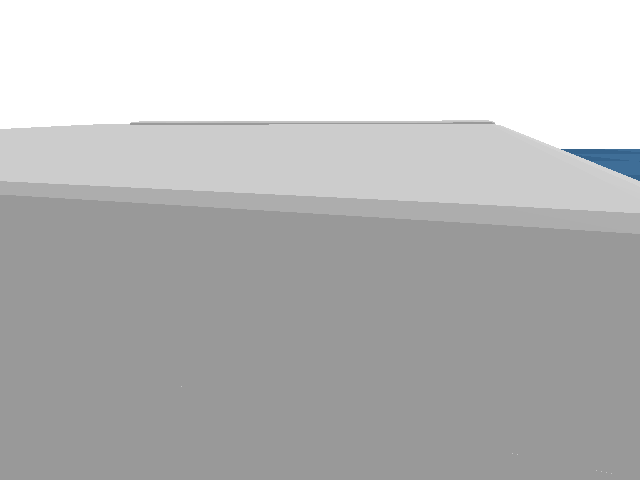

=== Side view (robot perspective) ===


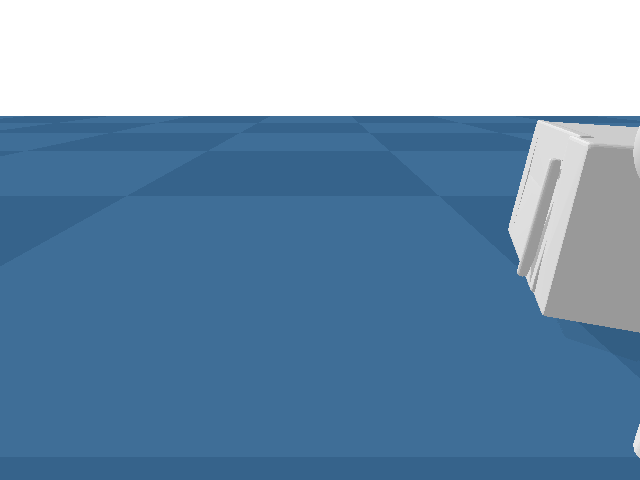

=== Top-down view ===


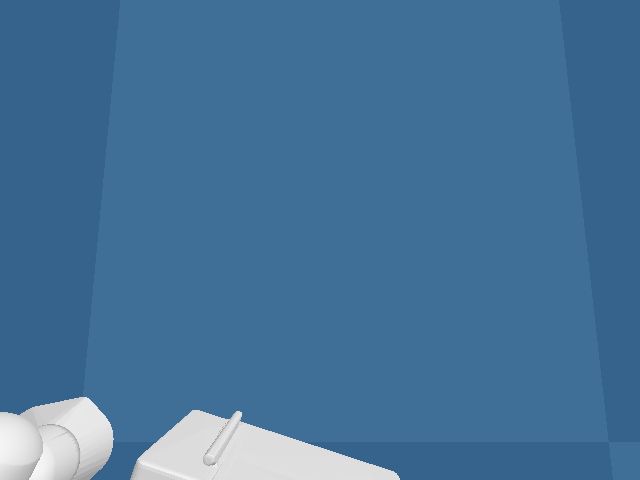

In [ ]:
# Show multiple views of the motion planning target
print("=== Multiple Views of Motion Planning Target ===")

views = [
    ("Front view", {"yaw": 0, "pitch": -15, "distance": 0.8}),
    ("Side view (robot perspective)", {"yaw": -90, "pitch": -20, "distance": 0.8}),
    ("Top-down view", {"yaw": 0, "pitch": -80, "distance": 0.8}),
]

for title, kwargs in views:
    display_scene(env.id, title, target_pos=list(grasp_pos_world), **kwargs)

## Step 12: Verify Grasp Reachability

Check if the grasp target is within the robot's workspace and compute the IK solution.

In [ ]:
# Verify grasp reachability
print("=== Grasp Reachability Analysis ===")

# Robot workspace analysis
robot_base = p.getBasePositionAndOrientation(env.robot.body, physicsClientId=env.id)[0]
robot_base = np.array(robot_base)

grasp_pos = np.array(grasp_pos_world)

# Distance from robot base to grasp
dist_xy = np.linalg.norm(grasp_pos[:2] - robot_base[:2])
dist_3d = np.linalg.norm(grasp_pos - robot_base)

print(f"Robot base position: {robot_base}")
print(f"Grasp target position: {grasp_pos}")
print(f"Distance (XY plane): {dist_xy:.3f}m")
print(f"Distance (3D): {dist_3d:.3f}m")
print()

# Typical Panda arm reach is ~0.855m
PANDA_REACH = 0.855
if dist_3d > PANDA_REACH:
    print(f"⚠️  WARNING: Grasp may be OUT OF REACH!")
    print(f"   Distance ({dist_3d:.3f}m) > Panda reach ({PANDA_REACH}m)")
elif dist_3d < 0.3:
    print(f"⚠️  WARNING: Grasp is very CLOSE to robot!")
    print(f"   Distance ({dist_3d:.3f}m) - may cause self-collision")
else:
    print(f"✓ Grasp is within reachable workspace")

# Check grasp height
if grasp_pos[2] < 0:
    print(f"⚠️  WARNING: Grasp is BELOW ground! z={grasp_pos[2]:.3f}m")
elif grasp_pos[2] > 0.8:
    print(f"⚠️  WARNING: Grasp is quite HIGH z={grasp_pos[2]:.3f}m")
else:
    print(f"✓ Grasp height is reasonable: z={grasp_pos[2]:.3f}m")

=== Grasp Reachability Analysis ===
Robot base position: [0. 0. 0.]
Grasp target position: [0.45628542 0.37967217 0.05067266]
Distance (XY plane): 0.594m
Distance (3D): 0.596m

✓ Grasp is within reachable workspace
✓ Grasp height is reasonable: z=0.051m


In [ ]:
# Try to compute IK solution for the grasp pose
print("=== IK Solution Test ===")

try:
    # Use PyBullet's built-in IK solver
    ik_solution = p.calculateInverseKinematics(
        env.robot.body,
        env.robot.right_end_effector,
        grasp_pos_world,
        grasp_orn_world,
        physicsClientId=env.id
    )
    
    print(f"IK Solution found:")
    print(f"  Joint angles: {[f'{a:.3f}' for a in ik_solution[:7]]}")
    
    # Apply the IK solution and check the resulting EEF pose
    env.robot.set_joint_angles(env.robot.right_arm_joint_indices, ik_solution[:7])
    for _ in range(10):
        p.stepSimulation(physicsClientId=env.id)
    
    actual_eef_pos, actual_eef_orn = env.robot.get_pos_orient(env.robot.right_end_effector)
    
    pos_error = np.linalg.norm(np.array(actual_eef_pos) - np.array(grasp_pos_world))
    print(f"\nIK Accuracy:")
    print(f"  Target position: {grasp_pos_world}")
    print(f"  Actual position: {actual_eef_pos}")
    print(f"  Position error: {pos_error:.4f}m")
    
    if pos_error < 0.01:
        print(f"✓ IK solution is accurate (error < 1cm)")
    elif pos_error < 0.05:
        print(f"⚠️  IK solution has moderate error ({pos_error:.3f}m)")
    else:
        print(f"⚠️  WARNING: Large IK error ({pos_error:.3f}m) - grasp may not be reachable!")
        
    # Check for collisions
    contact_obj = p.getContactPoints(env.robot.body, object_id, physicsClientId=env.id)
    contact_plane = p.getContactPoints(env.robot.body, env.urdf_ids['plane'], physicsClientId=env.id)
    
    if contact_obj:
        print(f"⚠️  WARNING: Robot collides with object at IK solution!")
    if contact_plane:
        print(f"⚠️  WARNING: Robot collides with ground at IK solution!")
    if not contact_obj and not contact_plane:
        print(f"✓ No collisions at IK solution")
        
except Exception as e:
    print(f"ERROR computing IK: {e}")

=== IK Solution Test ===
IK Solution found:
  Joint angles: ['-1.434', '-1.792', '1.863', '-1.140', '0.019', '1.379', '1.028']

IK Accuracy:
  Target position: (0.45628541707992554, 0.37967216968536377, 0.050672657787799835)
  Actual position: [0.46010327 0.40397688 0.0790446 ]
  Position error: 0.0376m
⚠️  IK solution has moderate error (0.038m)
⚠️  WARNING: Robot collides with ground at IK solution!


=== Robot at IK Solution for Grasp ===


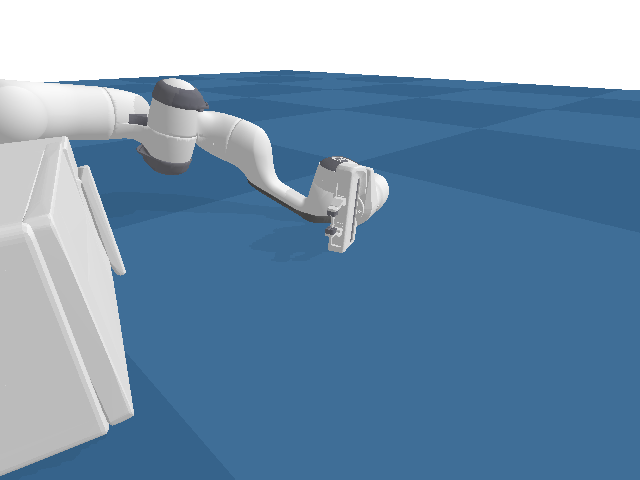

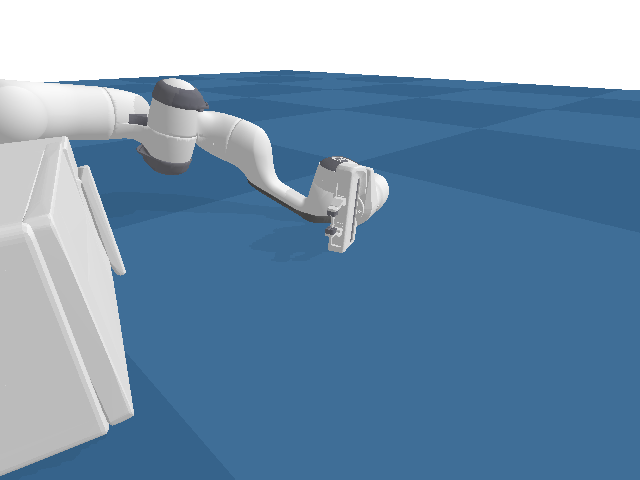

In [ ]:
# Display final scene with robot at IK solution
display_scene(env.id, "Robot at IK Solution for Grasp",
              target_pos=list(grasp_pos_world), distance=0.8, yaw=45, pitch=-25)

## Summary

This notebook helps visualize and debug the demo generation pipeline. Key things to check:

1. **Object pose**: Is the object placed in front of the robot (x≈0.4)?
2. **Grasp position**: Is the predicted grasp on the handle?
3. **Grasp orientation**: Does the approach direction (Z axis) point correctly?
4. **Gripper visualization**: Does the gripper visualization show reasonable finger positions?
5. **Pre-grasp pose**: Is the pre-grasp offset in the correct approach direction?
6. **Robot reachability**: Is the grasp within Panda arm's reach (~0.855m)?
7. **IK solution**: Does inverse kinematics find a valid solution?
8. **Collision-free**: Is the IK solution collision-free?

### Debugging Checklist
- [ ] Object placed at x≈0.4 (not at origin)
- [ ] Object sitting on ground (z≈0)
- [ ] Grasp point is on the object's handle
- [ ] Approach direction points toward the object
- [ ] Grasp is within robot workspace
- [ ] IK position error < 1cm
- [ ] No collisions at IK solution

In [ ]:
# Cleanup
env.close()
print("Environment closed.")

Environment closed.
